# 02 — Önişleme Karşılaştırması
Minimal (rescale+augmentation) vs. CLAHE görsel karşılaştırması.

In [1]:
import sys
sys.path.insert(0, '../src')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from preprocessing import apply_clahe, load_image

DATA_DIR = Path('../data/chest_xray/chest_xray')

## 1. CLAHE Öncesi / Sonrası Görsel Karşılaştırma

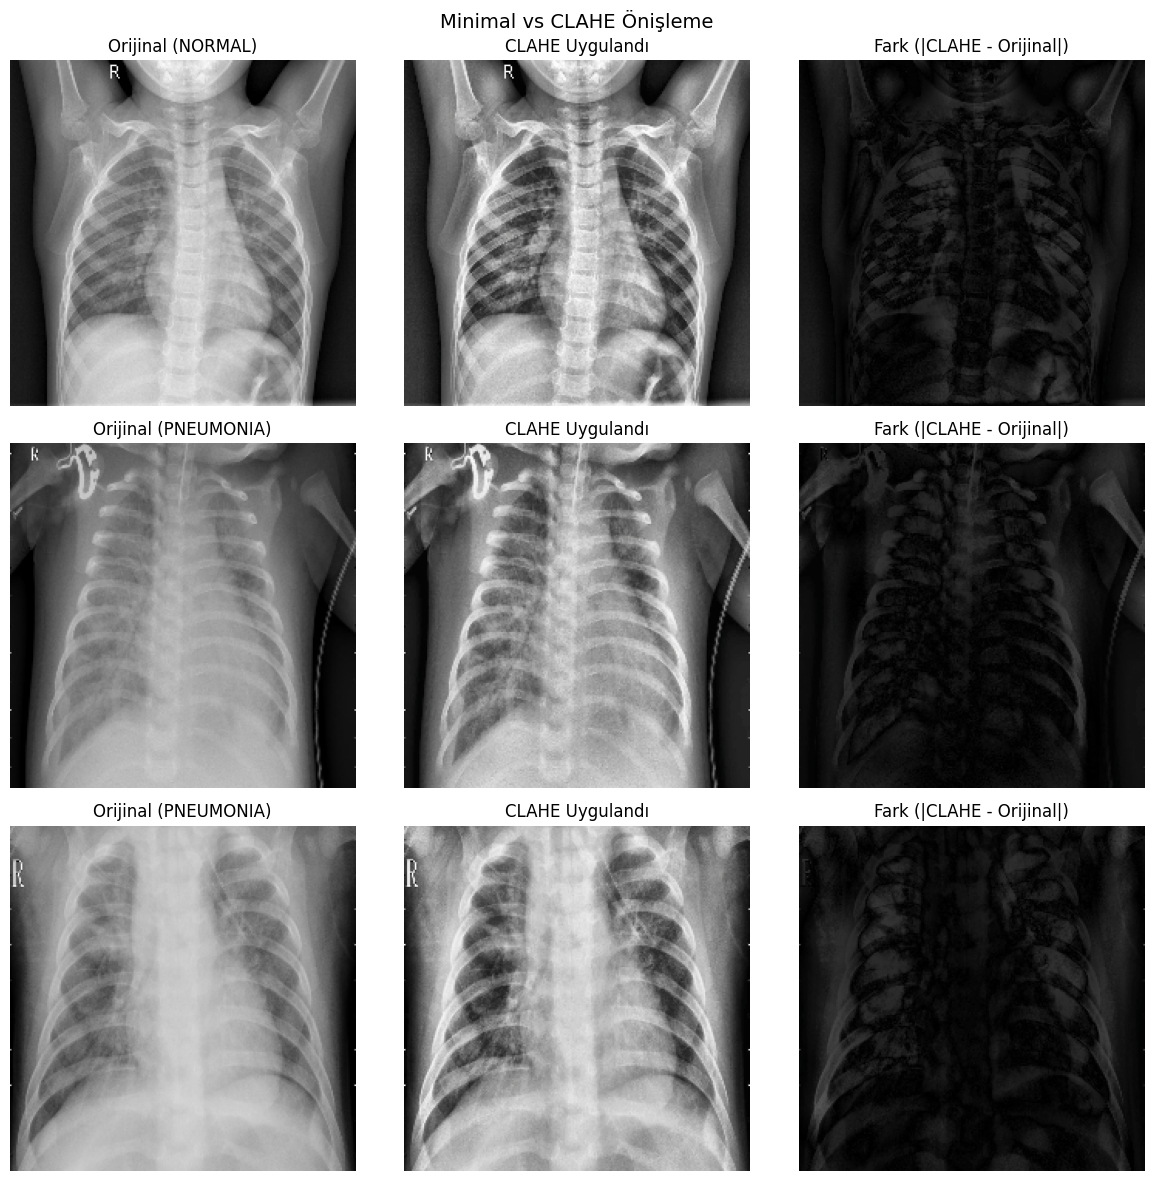

Görsel kaydedildi: results/figures/clahe_comparison.png


In [2]:
sample_paths = [
    list((DATA_DIR / 'train' / 'NORMAL').glob('*.jpeg'))[0],
    list((DATA_DIR / 'train' / 'PNEUMONIA').glob('*.jpeg'))[0],
    list((DATA_DIR / 'train' / 'PNEUMONIA').glob('*.jpeg'))[5],
]

fig, axes = plt.subplots(len(sample_paths), 3, figsize=(12, 4 * len(sample_paths)))

for row, path in enumerate(sample_paths):
    original = load_image(str(path))  # float32, 0-1
    clahe_img = apply_clahe(original)
    diff = np.abs(clahe_img - original)

    label = path.parent.name
    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f'Orijinal ({label})')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(clahe_img)
    axes[row, 1].set_title('CLAHE Uygulandı')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(diff, cmap='hot')
    axes[row, 2].set_title('Fark (|CLAHE - Orijinal|)')
    axes[row, 2].axis('off')

plt.suptitle('Minimal vs CLAHE Önişleme', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/clahe_comparison.png', dpi=150)
plt.show()
print('Görsel kaydedildi: results/figures/clahe_comparison.png')

## 2. Histogram Karşılaştırması

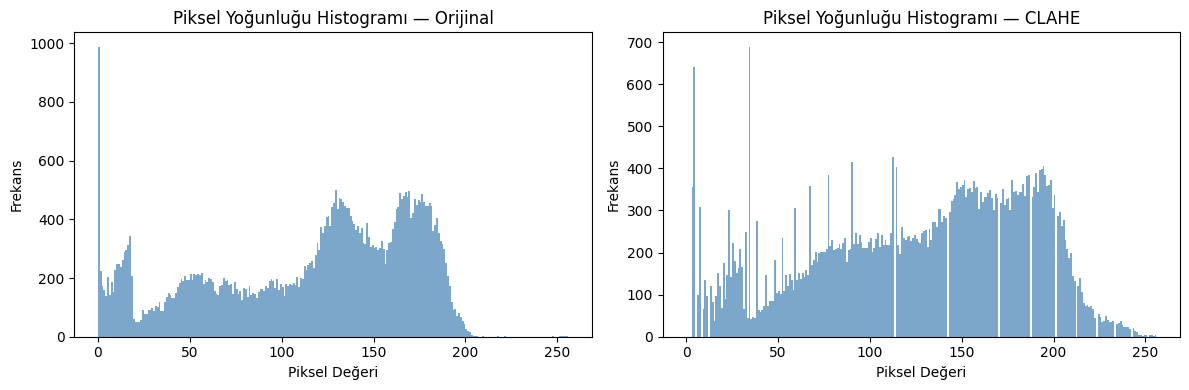

In [3]:
path = sample_paths[1]  # Pneumonia örneği
original = load_image(str(path))
clahe_img = apply_clahe(original)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (img, title) in zip(axes, [(original, 'Orijinal'), (clahe_img, 'CLAHE')]):
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    ax.hist(gray.ravel(), bins=256, range=(0, 256), color='steelblue', alpha=0.7)
    ax.set_title(f'Piksel Yoğunluğu Histogramı — {title}')
    ax.set_xlabel('Piksel Değeri')
    ax.set_ylabel('Frekans')

plt.tight_layout()
plt.savefig('../results/figures/histogram_comparison.png', dpi=150)
plt.show()

## 3. Augmentation Görseli

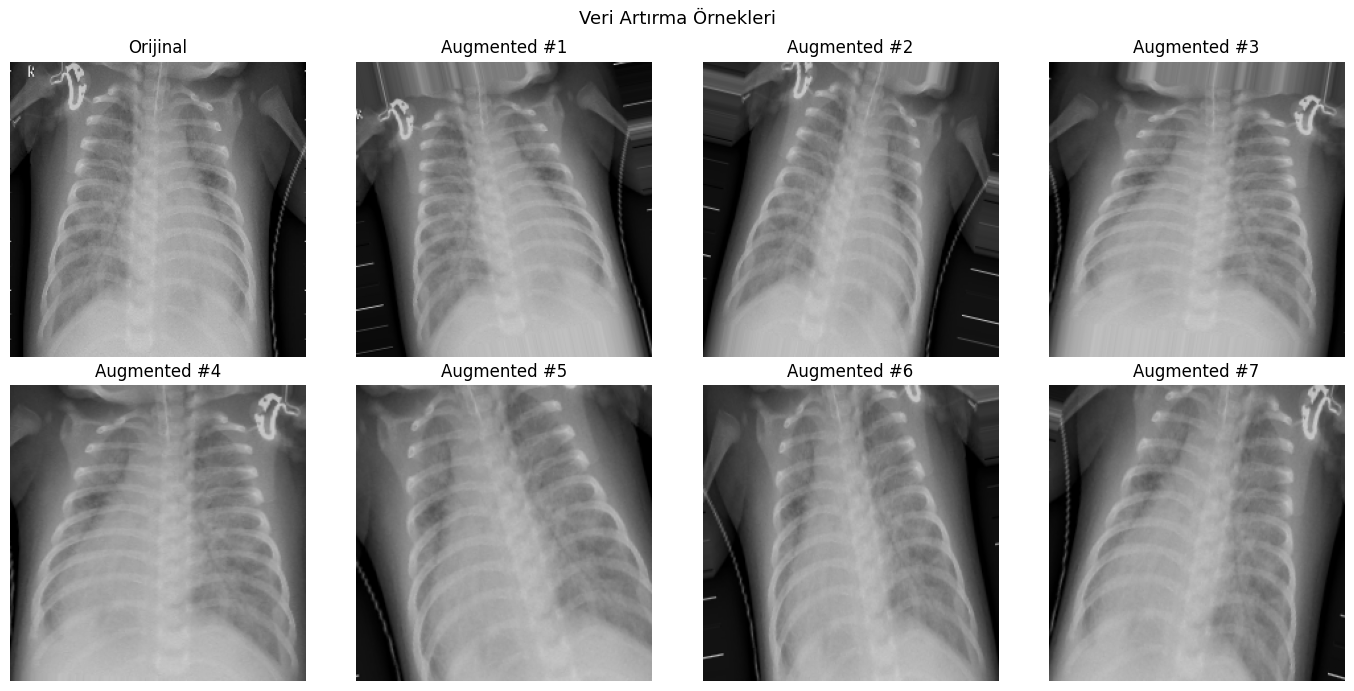

In [4]:
import tensorflow as tf

path = sample_paths[1]
original = load_image(str(path))

datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.2,
)

img_batch = original[np.newaxis]  # (1, 224, 224, 3)
aug_gen = datagen.flow(img_batch, batch_size=1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes[0, 0].imshow(original)
axes[0, 0].set_title('Orijinal')
axes[0, 0].axis('off')

for i, ax in enumerate(axes.ravel()[1:]):
    aug_img = next(aug_gen)[0]
    ax.imshow(np.clip(aug_img, 0, 1))
    ax.set_title(f'Augmented #{i+1}')
    ax.axis('off')

plt.suptitle('Veri Artırma Örnekleri', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/augmentation_samples.png', dpi=150)
plt.show()